# 1D profile interpolation

This short tutorial demonstrates how to use `smudgy` to interpolate a  profile from point observations to arbitrary coordinates in 1D.

`smudgy.utils` offers a helper function {py:func}`~smudgy.utils.create_grid_1d` (similar functions are available for 2D and 3D) to quickly construct equidistant coordinates. However, arbitrary coordinates can also be passed to the relevant methods.

First, let's import all the necessary packages and modules:

In [1]:
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np

import smudgy as sm
from smudgy.utils import create_grid_1d

[Taichi] version 1.7.4, llvm 15.0.7, commit b4b956fd, osx, python 3.13.14


[I 08/12/26 22:29:10.572 3047098] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


In [2]:
try:
    plt.style.use('custom')
except:
    pass
%matplotlib inline
%config InlineBackend.figure_format='retina'

## Interpolating a noisy profile

Let's generate a set of noisy observations at random positions. Here, we sample values from a Hernquist (1990) profile, describing the radial matter density in dark matter haloes, $\rho(r) = \rho_0 / [ (r / r_s) \cdot (1 + r / r_s)^3 ]$.

In [3]:
rng = np.random.default_rng(11)

RHO0 = 1.0
RS = 1.0

def true_profile(r):
    x = r / RS
    return RHO0 / (x * (1.0 + x) ** 3)

# ---------------------------------------------------------------------
# Generate noisy samples
# ---------------------------------------------------------------------
N = 1000
R_MIN, R_MAX = 0.001, 100.0

# Log-uniform sampling: typical of particle data that is denser near the
# center and sparser at large radii.
r_samples = np.exp(rng.uniform(np.log(R_MIN), np.log(R_MAX), size=N))
r_samples.sort()

rho_true_at_samples = true_profile(r_samples)

# Multiplicative (log-normal) noise, roughly mimicking Poisson-like
# shot noise in particle-based density estimates.
noise_sigma = 1
rho_noisy = rho_true_at_samples * np.exp(rng.normal(0.0, noise_sigma, size=N))


Next, we generate the coordinates where we want to interpolate our density values:

In [4]:
n_bins = 50
r_grid = np.exp(np.linspace(np.log(R_MIN), np.log(R_MAX), n_bins))[:, None]

Then, we setup a {py:class}`~smudgy.pointcloud.PointCloud` object and initialize them with positions and assign the density field via the {py:meth}`~smudgy.pointcloud.PointCloud.add_fields` method. Here, we fix the structure to `isotropic` (`covariant` is only available for 2 and 3D), the kernel to a gaussian and the number of neighbors to the ratio of number of samples to bins. Then we compute the smoothing lengths and density at the sample positions.

In [5]:
pc = sm.PointCloud(
    r_samples[:, None],
    backend="taichi",
).global_setup(structure="isotropic", kernel_name='gaussian', num_neighbors=N//n_bins)
pc.add_fields("rho_noisy", rho_noisy)

pc.compute_smoothing()
pc.compute_density()

[Taichi] Starting on arch=metal
[smudgy] Set taichi backend
[smudgy] Using 1 MPI rank
[smudgy] Initialized 1d PointCloud with 1000 particles without periodicity
[smudgy] Set structure to 'isotropic'
[smudgy] Set kernel to 'gaussian'
[smudgy] Set number of neighbors to 20
[smudgy] Building kd-tree from positions
[smudgy] Computing smoothing lengths from 20 neighbors
[smudgy] Computing density using isotropic 'gaussian' kernel


Next, we interpolate the density values onto our query positions:

In [6]:
rho_interp = pc.interpolate(fields="rho_noisy",
                            query_positions=r_grid, )

[smudgy] Interpolating fields at query positions using isotropic 'gaussian' kernel


and compare the results to the true underlying density profile:

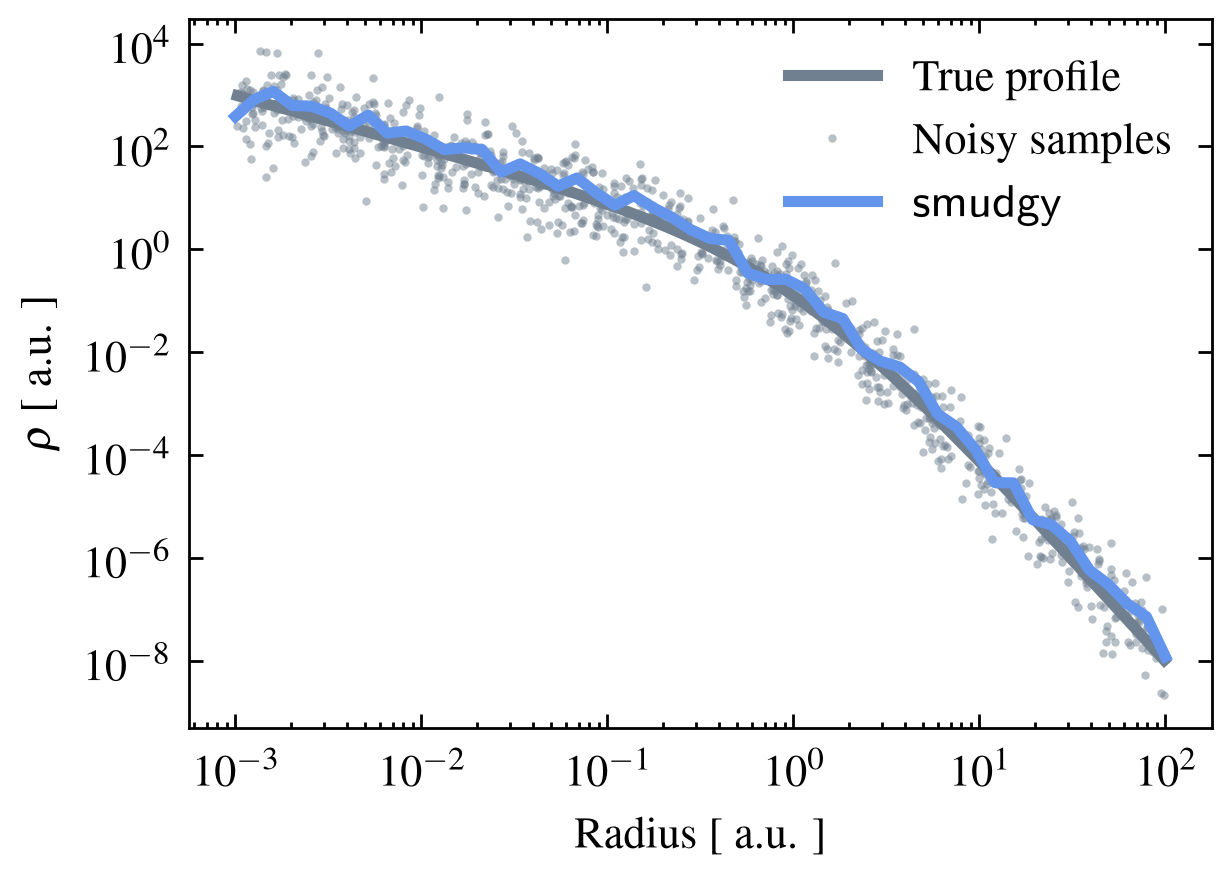

In [7]:
fig, ax = plt.subplots()
ax.loglog(r_samples, rho_true_at_samples, 
           alpha=1.0, lw=2, color='slategray',
           label='True profile')
ax.loglog(r_samples, rho_noisy, '.', 
           alpha=0.5, mec='none', ms=3, color='slategray',
           label='Noisy samples')
ax.loglog(r_grid, rho_interp, 
          color='cornflowerblue', lw=2, ls='-',
          label=r'\textsf{smudgy}')

ax.set_xlabel(r'Radius [ a.u. ]')
ax.set_ylabel(r'$\rho$ [ a.u. ]')
ax.legend()
fig.savefig('interpolation_1d.pdf', bbox_inches='tight', dpi=300)
plt.show()